<a href="https://colab.research.google.com/github/DigoShane/GitHub-ML/blob/main/02_pytorch_Classification_ZTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0.2 NN classification with pytorch.

In [44]:
import sklearn

In [45]:
from sklearn.datasets import make_circles

#Make thousand samples
n_samples = 1000

#Create circles
X, y = make_circles(n_samples, noise=0.03, random_state=42)

In [46]:
len(X), len(y)

(1000, 1000)

In [47]:
print(f"1st 10 sampls of X:\n {X[:10]}")
print(f"1st 10 sampls of y:\n {y[:10]}")

1st 10 sampls of X:
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]
 [-0.47964637  0.67643477]
 [-0.01364836  0.80334872]
 [ 0.77151327  0.14775959]
 [-0.16932234 -0.79345575]
 [-0.1214858   1.02150905]]
1st 10 sampls of y:
 [1 1 1 1 0 1 1 1 1 0]


In [48]:
import pandas as pd
circles = pd.DataFrame({"X1": X[:,0],
                        "X2": X[:,1],
                       "label": y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


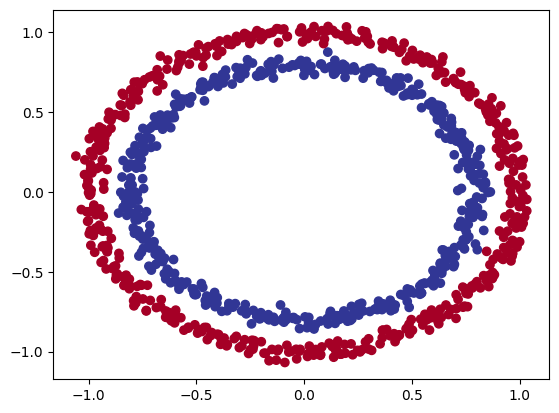

In [49]:
#Visualizing
import matplotlib.pyplot as plt

plt.scatter(x=X[:,0], y=X[:,1],
            c=0.5*y+0.5, #Color with labels - y (y from [2])
            cmap=plt.cm.RdYlBu)

# Data we are working with is a toy data set. Small enough to experiment on, but sizeable enough to practise fundamentals with.

## Check i/p and o/p shapes.

In [50]:
X.shape, y.shape

((1000, 2), (1000,))

In [51]:
X[0], y[0] # notice that its an arry from numpy. thats what sklearn creates.

(array([0.75424625, 0.23148074]), np.int64(1))

In [52]:
import torch

In [53]:
torch.__version__

'2.11.0+cu128'

In [54]:
X.dtype, type(X)

(dtype('float64'), numpy.ndarray)

In [55]:
#Converting data into tensors
X = torch.from_numpy(X).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32)

In [56]:
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [57]:
X.dtype, y.dtype

(torch.float32, torch.float32)

In [58]:
#splitting data.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## Building a Model

LEts build a model to classify blue and red dots.

To do this, we want to:
1. Setup device agnostic code, so your device will run on a GPU, if there is one.
2. Construct a model (by subclassing `nn.Module`)
3. Define a loss function and optimizer
4. Create a training and test loop

In [60]:
# import pytorch
import torch
from torch import nn
device = "cuda" if torch.cuda.is_available() else "cpu" # device agnostic code.
device

'cuda'

1. Subclass `nn.Module`
2. Create `nn.Linear()`
3. Define `forward()` method that outlines the forward pass
4. Instantiate an instance of our model class and send it to the target `device`

In [61]:
#1. Subclass nn.Module
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    #2. Create 2 nn.Linear()
    self.layer_1 = nn.Linear(in_features=2, out_features=5)
    self.layer_2 = nn.Linear(in_features=5, out_features=1)

  #3. Def forward pass
  def forward(self, x):
    return self.layer_2(self.layer_1(x))

#4. Instantiate an instanve of our model class and send it to the target class.
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [62]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [63]:
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188]], device='cuda:0')),
             ('layer_1.bias',
              tensor([0.6146, 0.1323, 0.5224, 0.0958, 0.3410], device='cuda:0')),
             ('layer_2.weight',
              tensor([[-0.0631,  0.3448,  0.0661, -0.2088,  0.1140]], device='cuda:0')),
             ('layer_2.bias', tensor([-0.2060], device='cuda:0'))])

In [64]:
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape:{untrained_preds.shape}")
print(f"Length of predictions: {len(X_test)}, Shape:{X_test.shape}")
print(f"1st 10 Predictions:\n {untrained_preds[:10]}")
print(f"1st 10 labels:\n {y_test[:10]}")

Length of predictions: 200, Shape:torch.Size([200, 1])
Length of predictions: 200, Shape:torch.Size([200, 2])
1st 10 Predictions:
 tensor([[-0.1269],
        [-0.0967],
        [-0.1908],
        [-0.1089],
        [-0.1667],
        [-0.1484],
        [-0.0826],
        [-0.0946],
        [-0.1918],
        [-0.0944]], device='cuda:0')
1st 10 labels:
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [65]:
### Loss functions and Optimizer
loss_fn = nn.BCEWithLogitsLoss() #Binary cross entropy with Logits.

optimizer = torch.optim.SGD(params=model_0.parameters(), lr =0.1)

In [66]:
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188]], device='cuda:0')),
             ('layer_1.bias',
              tensor([0.6146, 0.1323, 0.5224, 0.0958, 0.3410], device='cuda:0')),
             ('layer_2.weight',
              tensor([[-0.0631,  0.3448,  0.0661, -0.2088,  0.1140]], device='cuda:0')),
             ('layer_2.bias', tensor([-0.2060], device='cuda:0'))])

In [67]:
#Calculate Accuracy
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item() # .item() extracts the standard Python number out of the 0-dimensional PyTorch tensor.
  acc = (correct/len(y_pred)) * 100
  return acc

### Training a model

### 3.1 Going from raw logits -> prediction probabilities -> prediction labels

Our mode outputs are going to be raw **logits**

We can convert these **logits** into preciction probabilities by passing them to
some kind of activation fn: sigmoid for BinaryCrossEntropy and softmax for
Multiclass classification

then we can convert prediction probabilities to **prediction labels** by either
rounding them or taking the `argmax()`.

In [68]:
# view 1st 5 outputs of forward pass on test data
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.1269],
        [-0.0967],
        [-0.1908],
        [-0.1089],
        [-0.1667]], device='cuda:0')

In [69]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [70]:
# Use sigmoid activation fn on our model logits to turn them into prediction probabilities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4683],
        [0.4758],
        [0.4524],
        [0.4728],
        [0.4584]], device='cuda:0')

In [71]:
torch.round(y_pred_probs)

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]], device='cuda:0')

## 3.2 Building a Training and Testing loop

In [72]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put data tp target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

#Build training and evaluation loop
for epoch in range(epochs): # 1. for epochs in range

  model_0.train() #2. set the model train

  y_logits = model_0(X_train).squeeze() #3. do the forward pass
  y_pred = torch.round(torch.sigmoid(y_logits)) # Extra step. turn logits -> pred probs -> pred labels

  loss = loss_fn(y_logits, y_train)#4. Calculate the loss
  acc = accuracy_fn(y_true=y_train, y_pred=y_pred) # Note that if we had BCELoss (w/o logits) then the input would be the probabilities, ie sigmoid(logits).

  optimizer.zero_grad()#5. zero out the grad

  loss.backward()#6. Backward the Lass (Loss)

  optimizer.step()#7. Take a descent step (gradient descent)

  ### TEsting
  model_0.eval() #1. Call model dot eval
  with torch.inference_mode(): #2. With torch inference mode
    test_logits = model_0(X_test).squeeze()#3. Do the forward pass
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)#4. Calculate the loss
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

  #Print out what's happenin'. Yo.
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69569 | Acc: 50.00% | Test Loss: 0.69721 | Test Acc: 50.00%
Epoch: 10 | Loss: 0.69403 | Acc: 50.00% | Test Loss: 0.69615 | Test Acc: 50.00%
Epoch: 20 | Loss: 0.69343 | Acc: 46.00% | Test Loss: 0.69585 | Test Acc: 48.50%
Epoch: 30 | Loss: 0.69321 | Acc: 49.00% | Test Loss: 0.69577 | Test Acc: 47.50%
Epoch: 40 | Loss: 0.69312 | Acc: 49.50% | Test Loss: 0.69573 | Test Acc: 46.50%
Epoch: 50 | Loss: 0.69308 | Acc: 50.38% | Test Loss: 0.69569 | Test Acc: 46.50%
Epoch: 60 | Loss: 0.69306 | Acc: 50.50% | Test Loss: 0.69564 | Test Acc: 46.50%
Epoch: 70 | Loss: 0.69305 | Acc: 50.50% | Test Loss: 0.69559 | Test Acc: 46.50%
Epoch: 80 | Loss: 0.69304 | Acc: 50.75% | Test Loss: 0.69553 | Test Acc: 46.50%
Epoch: 90 | Loss: 0.69303 | Acc: 50.38% | Test Loss: 0.69547 | Test Acc: 46.50%


## 4. Make predictions and evaulate the model

From the metrics, it looks like our model isn't learning anything...

So to inspect it let's make some predictiona dn make it visual.

To do so, we will implement `plot_decision_boundary()`

In [73]:
import requests #To go to a website and request some code
from pathlib import Path

# Download helper fn if already not downloaded
if Path("helper_functions.py").is_file(): #If this path exists, ie already downloaded. Then don't download.
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f: # Write binary.
    f.write(request.content) #This is saying copy the whole code at 'request'. Create a file called helper_functions.py and write the contents of the url to it.

from helper_functions import plot_predictions, plot_decision_boundary


helper_functions.py already exists, skipping download


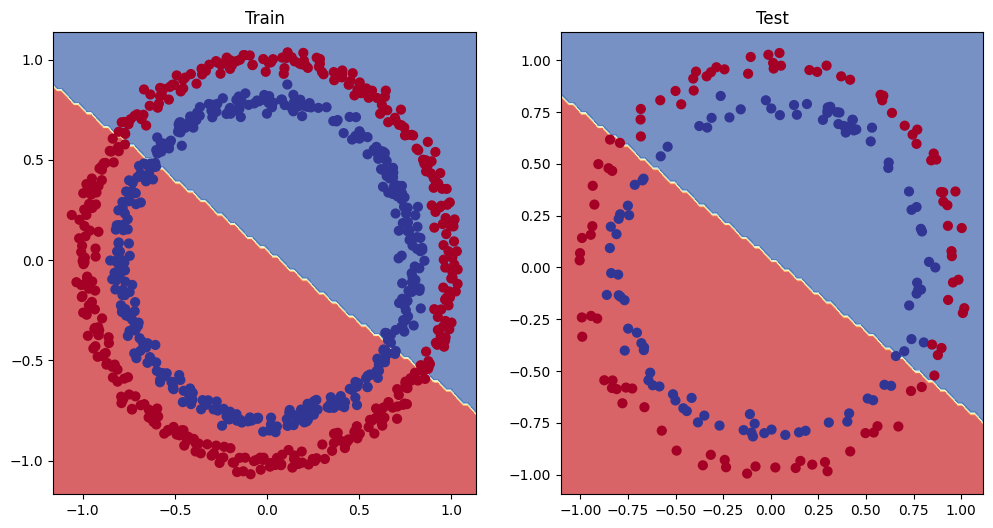

In [74]:
# Plot decision booundary of model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

# 5. Improing a model (from model perspective)

* Add more layers - give the model more chances to learn about patterns in the data.

* Add more hidden units

* Train for longer

* Changing the activation function

* Changing the learning rate.

* Changing the loss fn.

The above are from the model's perspective since they deal directly with the model. Another way to improve is to get better data.

In order to improve, we are using more hidden layers, Training for longer

In [75]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x):
    return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1


CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [76]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [77]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_1.train()

  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  ### Testing
  model_1.eval()
  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

  # PRint out whats happenin'
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69396 | Acc: 50.88% | Test Loss: 0.69261 | Test Acc: 51.00%
Epoch: 10 | Loss: 0.69369 | Acc: 50.25% | Test Loss: 0.69270 | Test Acc: 50.00%
Epoch: 20 | Loss: 0.69351 | Acc: 50.12% | Test Loss: 0.69283 | Test Acc: 49.50%
Epoch: 30 | Loss: 0.69339 | Acc: 50.50% | Test Loss: 0.69297 | Test Acc: 48.00%
Epoch: 40 | Loss: 0.69329 | Acc: 50.38% | Test Loss: 0.69310 | Test Acc: 49.00%
Epoch: 50 | Loss: 0.69322 | Acc: 49.88% | Test Loss: 0.69324 | Test Acc: 50.00%
Epoch: 60 | Loss: 0.69317 | Acc: 49.38% | Test Loss: 0.69336 | Test Acc: 51.50%
Epoch: 70 | Loss: 0.69312 | Acc: 49.38% | Test Loss: 0.69348 | Test Acc: 50.50%
Epoch: 80 | Loss: 0.69309 | Acc: 50.12% | Test Loss: 0.69359 | Test Acc: 50.00%
Epoch: 90 | Loss: 0.69307 | Acc: 50.50% | Test Loss: 0.69370 | Test Acc: 48.50%
Epoch: 100 | Loss: 0.69305 | Acc: 50.38% | Test Loss: 0.69379 | Test Acc: 48.00%
Epoch: 110 | Loss: 0.69303 | Acc: 50.88% | Test Loss: 0.69388 | Test Acc: 46.50%
Epoch: 120 | Loss: 0.69302 | Acc: 50.75

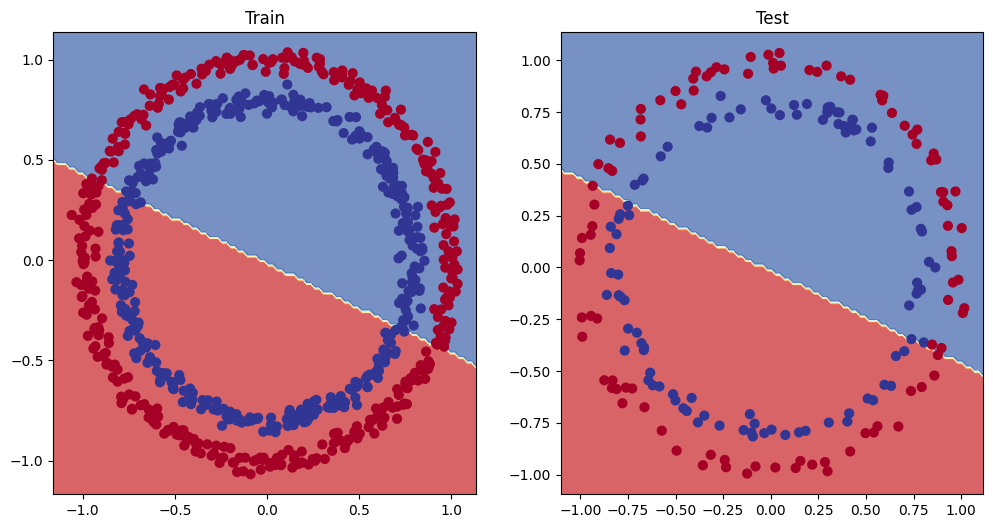

In [78]:
# Plot decision booundary of model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

## 6. Nonlinearity

What patterns could you draw if you were given an infinite amount of linear and nonlinear functions

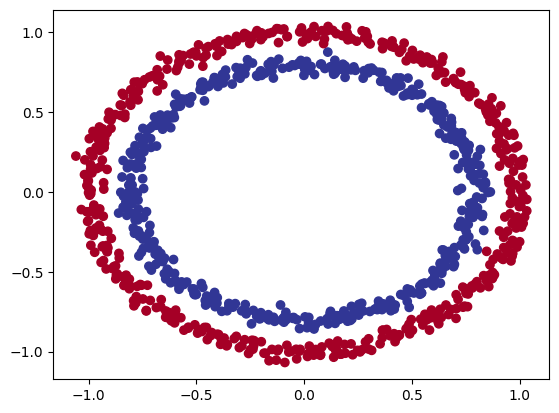

In [79]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples, noise=0.03, random_state=42)

plt.scatter(X[:,0],X[:,1], c=y, cmap=plt.cm.RdYlBu)

In [80]:
import torch
from sklearn.model_selection import train_test_split

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train[:10], y_train[:10]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994],
         [-0.8837, -0.4678],
         [-0.3836,  0.6987],
         [ 0.6047,  0.5163],
         [-0.5869,  0.7804],
         [ 0.8833, -0.5178]]),
 tensor([1., 0., 0., 0., 1., 0., 1., 1., 0., 0.]))

In [99]:
# Building a model with nonlinearity
from torch import nn
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()

  def forward(self, x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x))))) # Defining how the activation applies to the layers.

model_2 = CircleModelV2().to(device)
model_2

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [100]:
# Setup loss and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.1)

In [101]:
# Fit the model
torch.manual_seed(42)
epochs = 10000

# Put all data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    # 1. Forward pass
    y_logits = model_2(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> prediction probabilities -> prediction labels

    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train) # BCEWithLogitsLoss calculates loss using logits
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_2.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = model_2(X_test).squeeze()
      test_pred = torch.round(torch.sigmoid(test_logits)) # logits -> prediction probabilities -> prediction labels
      # 2. Calculate loss and accuracy
      test_loss = loss_fn(test_logits, y_test)
      test_acc = accuracy_fn(y_true=y_test,
                             y_pred=test_pred)

    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69295, Accuracy: 50.00% | Test Loss: 0.69319, Test Accuracy: 50.00%
Epoch: 100 | Loss: 0.69115, Accuracy: 52.88% | Test Loss: 0.69102, Test Accuracy: 52.50%
Epoch: 200 | Loss: 0.68977, Accuracy: 53.37% | Test Loss: 0.68940, Test Accuracy: 55.00%
Epoch: 300 | Loss: 0.68795, Accuracy: 53.00% | Test Loss: 0.68723, Test Accuracy: 56.00%
Epoch: 400 | Loss: 0.68517, Accuracy: 52.75% | Test Loss: 0.68411, Test Accuracy: 56.50%
Epoch: 500 | Loss: 0.68102, Accuracy: 52.75% | Test Loss: 0.67941, Test Accuracy: 56.50%
Epoch: 600 | Loss: 0.67515, Accuracy: 54.50% | Test Loss: 0.67285, Test Accuracy: 56.00%
Epoch: 700 | Loss: 0.66659, Accuracy: 58.38% | Test Loss: 0.66322, Test Accuracy: 59.00%
Epoch: 800 | Loss: 0.65160, Accuracy: 64.00% | Test Loss: 0.64757, Test Accuracy: 67.50%
Epoch: 900 | Loss: 0.62362, Accuracy: 74.00% | Test Loss: 0.62145, Test Accuracy: 79.00%
Epoch: 1000 | Loss: 0.56818, Accuracy: 87.75% | Test Loss: 0.57378, Test Accuracy: 86.50%
Epoch: 1100 | Loss: 0.

In [102]:
# Make predictions
model_2.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_2(X_test))).squeeze()
y_preds[:10], y[:10] # want preds in same format as truth labels

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0.]))

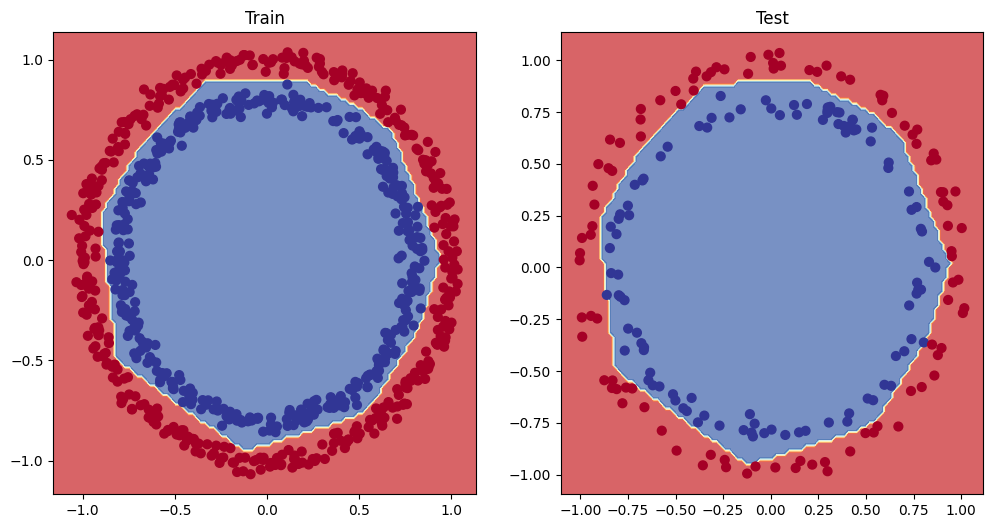

In [103]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_2, X_train, y_train) # model_1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_2, X_test, y_test) # model_3 = has non-linearity

### Multi-Class Classification

tensor([[-8.4134,  6.9352],
        [-5.7665, -6.4312],
        [-6.0421, -6.7661],
        [ 3.9508,  0.6984],
        [ 4.2505, -0.2815]]) tensor([3, 2, 2, 1, 1])


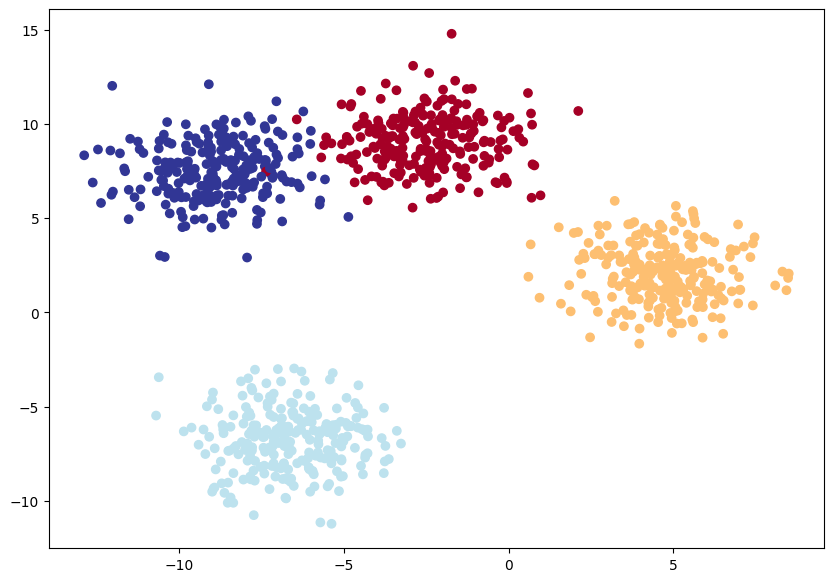

In [105]:
# Import dependencies
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples=1000,
    n_features=NUM_FEATURES, # X features
    centers=NUM_CLASSES, # y labels
    cluster_std=1.5, # give the clusters a little shake up (try changing this to 1.0, the default)
    random_state=RANDOM_SEED
)

# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)
print(X_blob[:5], y_blob[:5])

# 3. Split into train and test sets
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
    y_blob,
    test_size=0.2,
    random_state=RANDOM_SEED
)

# 4. Plot data
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu);

In [106]:
# Create device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [111]:
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    """ Initialize multiclass classification

    Args:
      input_features (int): No. of input features to the model
      output_features (int): No. of output features (no. of output classes)
      hidden_units (int): No. of hidden units between layers, default 8
    """
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features),
    )

  def forward(self, x):
    return self.linear_layer_stack(x)

model_3 = BlobModel(input_features=2, output_features=4).to(device)
model_3

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [110]:
 X_blob_train.shape, y_blob_train.shape

(torch.Size([800, 2]), torch.Size([800]))

In [112]:
# Loss function
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_3.parameters(), lr=0.1)

In [116]:
model_3(X_blob_test.to(device))[:10]

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834],
        [-0.1497, -1.0617, -0.7107, -0.1645],
        [ 0.1539, -0.2887,  0.1520, -0.0109],
        [-0.2154, -1.1795, -0.9300, -0.2745],
        [ 0.2443, -0.2472,  0.1649,  0.0061],
        [-0.2329, -1.2120, -0.9849, -0.3004]], device='cuda:0',
       grad_fn=<SliceBackward0>)